Q-Training Model (Revised)
- stateless Q-learning
- stronger convergence definition
- continuous + grid benchmark comparison
- steady-state average learned weights
- convergence speed (cumulative reward gap)
- hyperparameter and random-seed experiments

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
from itertools import product

In [30]:
# =========================================================
# 1. LOAD DATA
# =========================================================

outdir = Path("project3_outputs")

mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

# bounded action grid exported from optimalBenchmark.ipynb
action_file = outdir / "bounded_feasible_weights.csv"
weights_df = pd.read_csv(action_file)
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

# optional continuous bounded benchmark
continuous_benchmark_path = outdir / "bounded_benchmark_weights.csv"
continuous_benchmark_weights = None
if continuous_benchmark_path.exists():
    cont_df = pd.read_csv(continuous_benchmark_path)
    continuous_benchmark_weights = cont_df["weight"].values.astype(float)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)
print("Action file:", action_file)
print("Number of feasible actions:", len(action_grid))
print(weights_df.head())

if continuous_benchmark_weights is not None:
    print("Continuous benchmark weights:", continuous_benchmark_weights)

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]
Action file: project3_outputs/bounded_feasible_weights.csv
Number of feasible actions: 306
    w1   w2   w3
0 -0.5 -0.0  1.5
1 -0.5  0.1  1.4
2 -0.5  0.2  1.3
3 -0.5  0.3  1.2
4 -0.5  0.4  1.1
Continuous benchmark weights: [ 0.98354359 -0.5         0.51645641]


In [31]:
# =========================================================
# 2. REWARD + ENVIRONMENT
# =========================================================

def portfolio_return(weights, asset_returns):
    w = np.asarray(weights, dtype=float)
    r = np.asarray(asset_returns, dtype=float)

    if w.ndim != 1 or r.ndim != 1:
        raise ValueError("weights and asset_returns must both be 1D arrays")
    if w.shape[0] != r.shape[0]:
        raise ValueError("weights and asset_returns must have the same length")
    if not np.isfinite(w).all() or not np.isfinite(r).all():
        raise ValueError("weights and asset_returns must contain only finite values")

    return float(np.dot(w, r))


def reward_from_portfolio_return(portfolio_ret, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")
    rp = float(portfolio_ret)
    return float(rp - 0.5 * gamma * (rp ** 2))


def mean_variance_reward(weights, asset_returns, gamma):
    rp = portfolio_return(weights, asset_returns)
    return reward_from_portfolio_return(rp, gamma)


def sample_one_return(mu, Sigma, rng):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    return rng.multivariate_normal(mean=mu, cov=Sigma)

In [32]:
# =========================================================
# 3. BENCHMARKS
# =========================================================

def utility_from_moments(weights, mu, Sigma, gamma):
    w = np.asarray(weights, dtype=float)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    mean_ = float(w @ mu)
    var_ = float(w @ Sigma @ w)
    utility_ = float(mean_ - 0.5 * gamma * var_)
    return {
        "mean": mean_,
        "variance": var_,
        "utility": utility_,
    }


def best_grid_benchmark(action_grid, mu, Sigma, gamma):
    utilities = []
    for w in action_grid:
        u = utility_from_moments(w, mu, Sigma, gamma)["utility"]
        utilities.append(u)

    utilities = np.array(utilities)
    idx = int(np.argmax(utilities))

    return {
        "best_idx": idx,
        "best_weights": action_grid[idx],
        "best_utility": float(utilities[idx]),
        "all_utilities": utilities,
    }


def build_benchmark_bundle(action_grid, mu, Sigma, gamma, continuous_weights=None):
    grid_bench = best_grid_benchmark(action_grid, mu, Sigma, gamma)

    bundle = {
        "grid_idx": grid_bench["best_idx"],
        "grid_weights": grid_bench["best_weights"],
        "grid_stats": utility_from_moments(grid_bench["best_weights"], mu, Sigma, gamma),
    }

    if continuous_weights is not None:
        bundle["continuous_weights"] = continuous_weights
        bundle["continuous_stats"] = utility_from_moments(continuous_weights, mu, Sigma, gamma)
    else:
        bundle["continuous_weights"] = None
        bundle["continuous_stats"] = None

    return bundle

In [33]:
# =========================================================
# 4. Q-LEARNING
# =========================================================

def epsilon_greedy_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(Q)))
    return int(np.argmax(Q))


def compute_recent_average_weights(weight_history, window):
    if len(weight_history) < window:
        return None
    arr = np.asarray(weight_history[-window:], dtype=float)
    return arr.mean(axis=0)


def train_q_learning(
        mu,
        Sigma,
        action_grid,
        gamma=3.0,
        alpha=0.05,
        beta=0.001,
        discount=0.95,
        max_iter=50000,
        convergence_window=2000,   # kept only for compatibility
        q_tol=1e-6,                # kept only for compatibility
        weight_tol=5e-3,
        benchmark_tol=0.15,        # kept only for compatibility
        grid_benchmark_weights=None,
        seed=42,
        verbose=False
):
    """
    Stateless Q-learning:
        Q(a_t) <- Q(a_t) + alpha * [reward + discount * max_a' Q(a') - Q(a_t)]

    Convergence definition used in the write-up:
    the model is considered converged when the Euclidean distance
    between consecutive chosen portfolio weights w_t and w_{t-1}
    is sufficiently small.

    Here, "sufficiently small" means:
        || w_t - w_{t-1} ||_2 < weight_tol
    """
    rng = np.random.default_rng(seed)

    n_actions = len(action_grid)
    Q = np.zeros(n_actions, dtype=float)

    reward_history = []
    epsilon_history = []
    action_history = []
    best_action_history = []
    q_max_history = []
    q_change_history = []
    chosen_weight_history = []

    converged = False
    convergence_iter = None
    convergence_details = {}

    prev_w = None

    for t in range(1, max_iter + 1):
        epsilon = float(np.exp(-beta * t))
        old_Q = Q.copy()

        a_idx = epsilon_greedy_action(Q, epsilon, rng)
        w = action_grid[a_idx]

        r_next = sample_one_return(mu, Sigma, rng)
        reward = mean_variance_reward(w, r_next, gamma)

        td_target = reward + discount * np.max(Q)
        td_error = td_target - Q[a_idx]
        Q[a_idx] = Q[a_idx] + alpha * td_error

        current_best_idx = int(np.argmax(Q))
        q_change = float(np.max(np.abs(Q - old_Q)))

        reward_history.append(reward)
        epsilon_history.append(epsilon)
        action_history.append(a_idx)
        best_action_history.append(current_best_idx)
        q_max_history.append(float(np.max(Q)))
        q_change_history.append(q_change)
        chosen_weight_history.append(w.copy())

        # convergence rule from the write-up:
        # Euclidean distance between w_t and w_{t-1}
        if prev_w is not None:
            weight_distance = float(np.linalg.norm(w - prev_w))

            if weight_distance < weight_tol:
                converged = True
                convergence_iter = t
                convergence_details = {
                    "definition": "euclidean distance between consecutive weights",
                    "weight_distance": weight_distance,
                    "weight_tol": weight_tol,
                    "current_weights": w.copy(),
                    "previous_weights": prev_w.copy(),
                    # keep these keys for downstream compatibility
                    "formal_converged": converged,
                    "practical_converged": converged,
                    "best_action_stable": np.nan,
                    "q_changes_small": np.nan,
                    "weight_stable": converged,
                    "most_common_action_share": np.nan,
                    "q_small_share": np.nan,
                    "benchmark_distance": np.nan,
                    "recent_avg_weights": None,
                    "prev_avg_weights": None,
                }

                if verbose:
                    print(f"Converged at iteration {t}")
                    print(f"Current weights: {w}")
                    print(f"Previous weights: {prev_w}")
                    print(f"Euclidean distance: {weight_distance}")
                    print(f"Tolerance: {weight_tol}")
                break

        prev_w = w.copy()

    if not converged:
        convergence_iter = max_iter
        convergence_details = {
            "definition": "euclidean distance between consecutive weights",
            "weight_distance": np.nan,
            "weight_tol": weight_tol,
            "current_weights": chosen_weight_history[-1].copy() if len(chosen_weight_history) > 0 else None,
            "previous_weights": chosen_weight_history[-2].copy() if len(chosen_weight_history) > 1 else None,
            # keep these keys for downstream compatibility
            "formal_converged": False,
            "practical_converged": False,
            "best_action_stable": np.nan,
            "q_changes_small": np.nan,
            "weight_stable": False,
            "most_common_action_share": np.nan,
            "q_small_share": np.nan,
            "benchmark_distance": np.nan,
            "recent_avg_weights": None,
            "prev_avg_weights": None,
        }

        if verbose:
            print("Did not meet convergence rule before max_iter.")
            print(f"Using final iteration = {max_iter}")

    best_action_idx = int(np.argmax(Q))
    best_weights = action_grid[best_action_idx]

    return {
        "Q": Q,
        "best_action_idx": best_action_idx,
        "best_weights": best_weights,
        "reward_history": np.array(reward_history),
        "epsilon_history": np.array(epsilon_history),
        "action_history": np.array(action_history),
        "best_action_history": np.array(best_action_history),
        "q_max_history": np.array(q_max_history),
        "q_change_history": np.array(q_change_history),
        "chosen_weight_history": np.asarray(chosen_weight_history),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "convergence_details": convergence_details,
        "params": {
            "gamma": gamma,
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "max_iter": max_iter,
            "convergence_window": convergence_window,
            "q_tol": q_tol,
            "weight_tol": weight_tol,
            "seed": seed,
        },
    }

In [34]:
# =========================================================
# 5. TRAINING-PATH AVERAGE WEIGHTS + FIXED-POLICY EVALUATION
# =========================================================

def average_learned_weights_from_training(train_result, window=None):
    """
    Compute average learned weights directly from the realized training path.

    This is closer to the project requirement
        wbar_QL = (1/T) * sum_t w_t^{QL}
    than simply repeating the final best action.
    """
    weight_history = np.asarray(train_result["chosen_weight_history"], dtype=float)

    if weight_history.ndim != 2 or len(weight_history) == 0:
        raise ValueError("chosen_weight_history is empty or malformed")

    if window is not None:
        if window <= 0:
            raise ValueError("window must be positive")
        window = min(window, len(weight_history))
        weight_history = weight_history[-window:]

    return weight_history.mean(axis=0)


def fixed_policy_evaluation(
        learned_weights,
        mu,
        Sigma,
        gamma,
        T=5000,
        seed=999
):
    """
    Evaluate a fixed portfolio policy after training.

    This is a supplementary diagnostic.
    The main 'average learned weights' comparison should come
    from average_learned_weights_from_training(...).
    """
    rng = np.random.default_rng(seed)

    weights_path = []
    rewards = []
    returns = []

    learned_weights = np.asarray(learned_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)
        rp = portfolio_return(learned_weights, r_next)
        rw = reward_from_portfolio_return(rp, gamma)

        weights_path.append(learned_weights.copy())
        returns.append(rp)
        rewards.append(rw)

    weights_path = np.asarray(weights_path)
    returns = np.asarray(returns)
    rewards = np.asarray(rewards)

    return {
        "avg_fixed_policy_weights": weights_path.mean(axis=0),
        "mean_portfolio_return": float(returns.mean()),
        "var_portfolio_return": float(returns.var(ddof=1)),
        "mean_reward": float(rewards.mean()),
        "weights_path": weights_path,
        "returns": returns,
        "rewards": rewards,
    }

In [35]:
# =========================================================
# 6. CONVERGENCE SPEED / SAME-PATH COMPARISON
# =========================================================

def compare_policies_on_same_path(
        learned_weights,
        grid_benchmark_weights,
        mu,
        Sigma,
        gamma,
        T=5000,
        seed=2025,
        continuous_benchmark_weights=None
):
    """
    Compare learned policy and benchmark policies on the same simulated path.
    """
    rng = np.random.default_rng(seed)

    learned_rewards = []
    grid_rewards = []
    cont_rewards = [] if continuous_benchmark_weights is not None else None

    learned_weights = np.asarray(learned_weights, dtype=float)
    grid_benchmark_weights = np.asarray(grid_benchmark_weights, dtype=float)
    if continuous_benchmark_weights is not None:
        continuous_benchmark_weights = np.asarray(continuous_benchmark_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)

        rp_learned = portfolio_return(learned_weights, r_next)
        rp_grid = portfolio_return(grid_benchmark_weights, r_next)

        learned_rewards.append(reward_from_portfolio_return(rp_learned, gamma))
        grid_rewards.append(reward_from_portfolio_return(rp_grid, gamma))

        if continuous_benchmark_weights is not None:
            rp_cont = portfolio_return(continuous_benchmark_weights, r_next)
            cont_rewards.append(reward_from_portfolio_return(rp_cont, gamma))

    learned_rewards = np.asarray(learned_rewards)
    grid_rewards = np.asarray(grid_rewards)

    out = {
        "learned_rewards": learned_rewards,
        "grid_rewards": grid_rewards,
        "grid_reward_gap": grid_rewards - learned_rewards,
        "cum_grid_reward_gap": np.cumsum(grid_rewards - learned_rewards),
        "mean_grid_reward_gap": float(np.mean(grid_rewards - learned_rewards)),
    }

    if continuous_benchmark_weights is not None:
        cont_rewards = np.asarray(cont_rewards)
        out["continuous_rewards"] = cont_rewards
        out["continuous_reward_gap"] = cont_rewards - learned_rewards
        out["cum_continuous_reward_gap"] = np.cumsum(cont_rewards - learned_rewards)
        out["mean_continuous_reward_gap"] = float(np.mean(cont_rewards - learned_rewards))

    return out

In [36]:
# =========================================================
# 7. HYPERPARAMETER + SEED EXPERIMENTS
# =========================================================

def run_hyperparameter_seed_experiments(
        mu,
        Sigma,
        action_grid,
        gamma,
        alpha_list,
        beta_list,
        discount_list,
        seed_list,
        max_iter=50000,
        convergence_window=2000,
        q_tol=1e-10,
        weight_tol=1e-4,
        continuous_weights=None,
):
    benchmarks = build_benchmark_bundle(
        action_grid=action_grid,
        mu=mu,
        Sigma=Sigma,
        gamma=gamma,
        continuous_weights=continuous_weights,
    )

    rows = []
    detailed_runs = []

    total_runs = len(alpha_list) * len(beta_list) * len(discount_list) * len(seed_list)
    run_counter = 0

    for alpha, beta, discount, seed in product(alpha_list, beta_list, discount_list, seed_list):
        run_counter += 1
        print(f"Running {run_counter}/{total_runs} | alpha={alpha}, beta={beta}, discount={discount}, seed={seed}")

        result = train_q_learning(
            mu=mu,
            Sigma=Sigma,
            action_grid=action_grid,
            gamma=gamma,
            alpha=alpha,
            beta=beta,
            discount=discount,
            max_iter=max_iter,
            convergence_window=convergence_window,
            q_tol=q_tol,
            weight_tol=weight_tol,
            benchmark_tol=0.15,
            grid_benchmark_weights=benchmarks["grid_weights"],
            seed=seed,
            verbose=False,
        )

        learned_weights = result["best_weights"]
        avg_training_weights = average_learned_weights_from_training(
            result,
            window=min(convergence_window, len(result["chosen_weight_history"]))
        )

        learned_stats = utility_from_moments(learned_weights, mu, Sigma, gamma)
        avg_training_stats = utility_from_moments(avg_training_weights, mu, Sigma, gamma)

        distance_to_grid = float(np.linalg.norm(learned_weights - benchmarks["grid_weights"]))
        distance_avg_training_to_grid = float(np.linalg.norm(avg_training_weights - benchmarks["grid_weights"]))

        utility_gap_to_grid = float(benchmarks["grid_stats"]["utility"] - learned_stats["utility"])
        utility_gap_avg_training_to_grid = float(
            benchmarks["grid_stats"]["utility"] - avg_training_stats["utility"]
        )

        if benchmarks["continuous_weights"] is not None:
            distance_to_cont = float(np.linalg.norm(learned_weights - benchmarks["continuous_weights"]))
            distance_avg_training_to_cont = float(
                np.linalg.norm(avg_training_weights - benchmarks["continuous_weights"])
            )

            utility_gap_to_cont = float(benchmarks["continuous_stats"]["utility"] - learned_stats["utility"])
            utility_gap_avg_training_to_cont = float(
                benchmarks["continuous_stats"]["utility"] - avg_training_stats["utility"]
            )
        else:
            distance_to_cont = np.nan
            distance_avg_training_to_cont = np.nan
            utility_gap_to_cont = np.nan
            utility_gap_avg_training_to_cont = np.nan

        row = {
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "seed": seed,
            "converged": result["converged"],
            "convergence_iter": result["convergence_iter"],
            "best_action_idx": result["best_action_idx"],
            "w1": learned_weights[0],
            "w2": learned_weights[1],
            "w3": learned_weights[2],
            "avg_train_w1": avg_training_weights[0],
            "avg_train_w2": avg_training_weights[1],
            "avg_train_w3": avg_training_weights[2],
            "distance_to_grid_benchmark": distance_to_grid,
            "distance_to_continuous_benchmark": distance_to_cont,
            "distance_avg_training_to_grid": distance_avg_training_to_grid,
            "distance_avg_training_to_continuous": distance_avg_training_to_cont,
            "learned_mean": learned_stats["mean"],
            "learned_variance": learned_stats["variance"],
            "learned_utility": learned_stats["utility"],
            "grid_benchmark_utility": benchmarks["grid_stats"]["utility"],
            "utility_gap_to_grid": utility_gap_to_grid,
            "utility_gap_to_continuous": utility_gap_to_cont,
            "utility_gap_avg_training_to_grid": utility_gap_avg_training_to_grid,
            "utility_gap_avg_training_to_continuous": utility_gap_avg_training_to_cont,
            "grid_w1": benchmarks["grid_weights"][0],
            "grid_w2": benchmarks["grid_weights"][1],
            "grid_w3": benchmarks["grid_weights"][2],
        }

        rows.append(row)

        detailed_runs.append({
            "config": {
                "alpha": alpha,
                "beta": beta,
                "discount": discount,
                "seed": seed,
            },
            "result": result,
        })

    results_df = pd.DataFrame(rows)
    return results_df, detailed_runs, benchmarks

# Extra Credit

In [37]:
# =========================================================
# 1. LOAD DATA — LONG ONLY
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize

outdir = Path("project3_outputs")

# these are created in covMean(3).ipynb cells 8–10
mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

# ---------------------------------------------------------
# build LONG-ONLY action grid (instead of bounded grid)
# ---------------------------------------------------------
step = 0.1
values = np.round(np.arange(0.0, 1.0 + step / 2, step), 10)

feasible_actions = []
for w1 in values:
    for w2 in values:
        w3 = 1.0 - w1 - w2
        if w3 >= -1e-10:
            feasible_actions.append([round(w1, 10), round(w2, 10), round(max(w3, 0.0), 10)])

weights_df = pd.DataFrame(feasible_actions, columns=["w1", "w2", "w3"])
weights_df = weights_df.drop_duplicates().reset_index(drop=True)
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

# ---------------------------------------------------------
# continuous LONG-ONLY benchmark (instead of bounded benchmark)
# ---------------------------------------------------------
gamma = 3.0

def neg_utility_long_only(w):
    return -(mu_hat @ w - 0.5 * gamma * (w @ Sigma_hat @ w))

constraints_long = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds_long = [(0.0, None), (0.0, None), (0.0, None)]

best_util_long = -np.inf
best_w_long = None
best_res_long = None

long_guesses = [
    [1/3, 1/3, 1/3],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.6, 0.1, 0.3],
    [0.2, 0.6, 0.2],
    [0.1, 0.2, 0.7],
]

for guess in long_guesses:
    guess = np.array(guess, dtype=float)

    res = minimize(
        neg_utility_long_only,
        x0=guess,
        method="SLSQP",
        bounds=bounds_long,
        constraints=constraints_long,
        options={"ftol": 1e-15, "maxiter": 1000},
    )

    if res.success and -res.fun > best_util_long:
        best_util_long = -res.fun
        best_w_long = res.x
        best_res_long = res

if best_w_long is None:
    raise RuntimeError("Long-only optimization failed.")

continuous_benchmark_weights = np.asarray(best_w_long, dtype=float)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)
print("Number of long-only feasible actions:", len(action_grid))
print(weights_df.head())
print("Continuous long-only benchmark weights:", continuous_benchmark_weights)

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]
Number of long-only feasible actions: 66
    w1   w2   w3
0  0.0  0.0  1.0
1  0.0  0.1  0.9
2  0.0  0.2  0.8
3  0.0  0.3  0.7
4  0.0  0.4  0.6
Continuous long-only benchmark weights: [0.818372 0.       0.181628]


In [38]:
# =========================================================
# LONG-ONLY Q-LEARNING HYPERPARAMETER TUNING BLOCK
# Drop-in block for qTrainingModel(6).ipynb
# Assumes your helper functions (e.g. run_hyperparameter_seed_experiments)
# are already defined below/above as in your notebook.
# =========================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ---------------------------------------------------------
# 1. Load moments from covMean outputs
# ---------------------------------------------------------
outdir = Path("project3_outputs")

mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)

# ---------------------------------------------------------
# 2. Build LONG-ONLY action grid
# step size = 0.1, w_i >= 0, sum(w)=1
# ---------------------------------------------------------
step = 0.1
values = np.round(np.arange(0.0, 1.0 + step / 2, step), 10)

feasible_actions = []
for w1 in values:
    for w2 in values:
        w3 = 1.0 - w1 - w2
        if w3 >= -1e-10:
            feasible_actions.append([
                round(w1, 10),
                round(w2, 10),
                round(max(w3, 0.0), 10)
            ])

weights_df = pd.DataFrame(feasible_actions, columns=["w1", "w2", "w3"])
weights_df = weights_df.drop_duplicates().reset_index(drop=True)
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

print("Number of long-only feasible actions:", len(action_grid))
print(weights_df.head())

# ---------------------------------------------------------
# 3. Compute continuous LONG-ONLY benchmark
# ---------------------------------------------------------
gamma = 3.0

def neg_utility_long_only(w):
    return -(mu_hat @ w - 0.5 * gamma * (w @ Sigma_hat @ w))

constraints_long = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds_long = [(0.0, None)] * len(mu_hat)

long_guesses = [
    [1/3, 1/3, 1/3],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.6, 0.1, 0.3],
    [0.2, 0.6, 0.2],
    [0.1, 0.2, 0.7],
]

best_util_long = -np.inf
best_w_long = None

for guess in long_guesses:
    guess = np.array(guess, dtype=float)

    res = minimize(
        neg_utility_long_only,
        x0=guess,
        method="SLSQP",
        bounds=bounds_long,
        constraints=constraints_long,
        options={"ftol": 1e-15, "maxiter": 1000},
    )

    if res.success and -res.fun > best_util_long:
        best_util_long = -res.fun
        best_w_long = res.x.copy()

if best_w_long is None:
    raise RuntimeError("Long-only optimization failed.")

continuous_benchmark_weights = np.asarray(best_w_long, dtype=float)

print("Continuous long-only benchmark weights:", continuous_benchmark_weights)
print("Continuous long-only benchmark utility:", best_util_long)

# ---------------------------------------------------------
# 4. Hyperparameter grid
# ---------------------------------------------------------
alpha_list = [0.005, 0.01, 0.02, 0.05]
beta_list = [0.0005, 0.001, 0.002]
discount_list = [0.0, 0.5, 0.9, 0.95, 0.99]
seed_list = [42, 123, 2024]

max_iter = 500000
convergence_window = 2000
q_tol = 1e-6
weight_tol = 5e-3

# ---------------------------------------------------------
# 5. Run long-only hyperparameter experiments
# ---------------------------------------------------------
results_df, detailed_runs, benchmarks = run_hyperparameter_seed_experiments(
    mu=mu_hat,
    Sigma=Sigma_hat,
    action_grid=action_grid,
    gamma=gamma,
    alpha_list=alpha_list,
    beta_list=beta_list,
    discount_list=discount_list,
    seed_list=seed_list,
    max_iter=max_iter,
    convergence_window=convergence_window,
    q_tol=q_tol,
    weight_tol=weight_tol,
    continuous_weights=continuous_benchmark_weights,
)

print("\n===== Long-Only Benchmarks =====")
print("Grid benchmark weights:", benchmarks["grid_weights"])
print("Grid benchmark utility:", benchmarks["grid_stats"]["utility"])
print("Continuous benchmark weights:", benchmarks["continuous_weights"])
print("Continuous benchmark utility:", benchmarks["continuous_stats"]["utility"])

# ---------------------------------------------------------
# 6. Show best runs
# ---------------------------------------------------------
display_cols = [
    "alpha", "beta", "discount", "seed",
    "final_distance_to_grid",
    "final_distance_to_continuous",
    "utility_gap_to_grid",
    "utility_gap_to_continuous"
]

existing_display_cols = [c for c in display_cols if c in results_df.columns]

print("\n===== Best runs by utility gap to grid =====")
display(results_df[existing_display_cols].sort_values("utility_gap_to_grid").head(10))

# ---------------------------------------------------------
# 7. Save long-only results separately
# ---------------------------------------------------------
results_path = outdir / "q_learning_hyperparameter_seed_results_long_only.csv"
results_df.to_csv(results_path, index=False)

print("\nSaved long-only results to:", results_path)

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]
Number of long-only feasible actions: 66
    w1   w2   w3
0  0.0  0.0  1.0
1  0.0  0.1  0.9
2  0.0  0.2  0.8
3  0.0  0.3  0.7
4  0.0  0.4  0.6
Continuous long-only benchmark weights: [0.818372 0.       0.181628]
Continuous long-only benchmark utility: 0.00036086537308966147
Running 1/180 | alpha=0.005, beta=0.0005, discount=0.0, seed=42
Running 2/180 | alpha=0.005, beta=0.0005, discount=0.0, seed=123
Running 3/180 | alpha=0.005, beta=0.0005, discount=0.0, seed=2024
Running 4/180 | alpha=0.005, beta=0.0005, discount=0.5, seed=42
Running 5/180 | alpha=0.005, beta=0.0005, discount=0.5, seed=123
Running 6/180 | alpha=0.005, beta=0.0005, discount=0.5, seed=2024
Running 7/180 | alpha=0.005, beta=0.0005, discount=0.9, seed=42
Running 8/180 | alpha=0.005, beta=0.00

,alpha,beta,discount,seed,utility_gap_to_grid,utility_gap_to_continuous
178,0.050,0.0020,0.99,123,0.000002,0.000002
175,0.050,0.0020,0.95,123,0.000002,0.000002
172,0.050,0.0020,0.90,123,0.000002,0.000002
0,0.005,0.0005,0.00,42,0.000024,0.000024
120,0.020,0.0020,0.00,42,0.000024,0.000024
60,0.010,0.0010,0.00,42,0.000024,0.000024
123,0.020,0.0020,0.50,42,0.000024,0.000024
57,0.010,0.0005,0.99,42,0.000024,0.000024
126,0.020,0.0020,0.90,42,0.000024,0.000024
54,0.010,0.0005,0.95,42,0.000024,0.000024



Saved long-only results to: project3_outputs/q_learning_hyperparameter_seed_results_long_only.csv


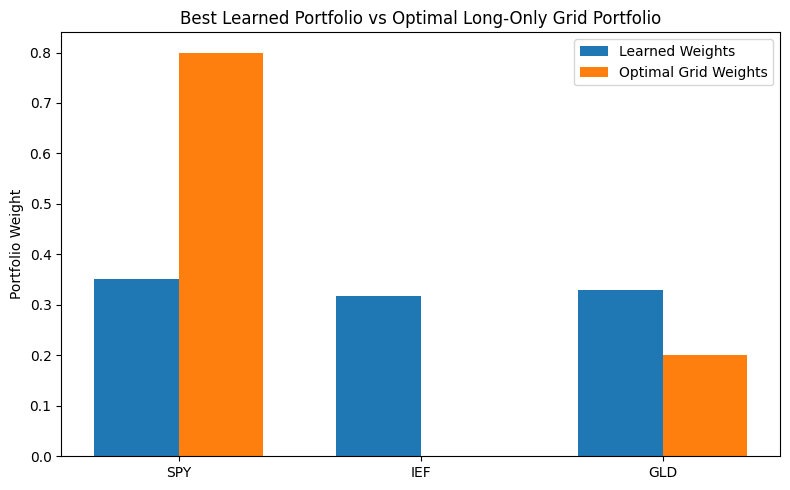

Best hyperparameters:
alpha       0.005
beta        0.002
discount      0.0
seed          123
Name: 31, dtype: object

Learned weights:
{'SPY': np.float64(0.352), 'IEF': np.float64(0.318), 'GLD': np.float64(0.33)}

Optimal grid weights:
{'SPY': np.float64(0.8), 'IEF': np.float64(0.0), 'GLD': np.float64(0.2)}


In [39]:
# ---------------------------------------------------------
# PLOT: learned weights vs optimal portfolio weights
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# choose the best run by avg-training utility gap to grid
best_row = results_df.sort_values(
    by=["utility_gap_avg_training_to_grid", "distance_avg_training_to_grid"],
    ascending=[True, True]
).iloc[0]

learned_weights = np.array([
    best_row["avg_train_w1"],
    best_row["avg_train_w2"],
    best_row["avg_train_w3"]
], dtype=float)

optimal_weights = np.array(benchmarks["grid_weights"], dtype=float)

labels = asset_names if "asset_names" in globals() else ["SPY", "IEF", "GLD"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, learned_weights, width, label="Learned Weights")
ax.bar(x + width/2, optimal_weights, width, label="Optimal Grid Weights")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Portfolio Weight")
ax.set_title("Best Learned Portfolio vs Optimal Long-Only Grid Portfolio")
ax.legend()

plt.tight_layout()
plt.show()

print("Best hyperparameters:")
print(best_row[["alpha", "beta", "discount", "seed"]])

print("\nLearned weights:")
print(dict(zip(labels, learned_weights.round(4))))

print("\nOptimal grid weights:")
print(dict(zip(labels, optimal_weights.round(4))))

In [40]:
best_row = results_df.sort_values(
    by=["utility_gap_to_grid", "distance_to_grid_benchmark"],
    ascending=[True, True]
).iloc[0]

learned_weights = np.array([
    best_row["w1"],
    best_row["w2"],
    best_row["w3"]
], dtype=float)

optimal_weights = np.array(benchmarks["grid_weights"], dtype=float)

In [41]:
best_row = results_df.sort_values(
    by=["utility_gap_to_grid", "distance_to_grid_benchmark"],
    ascending=[True, True]
).iloc[0]

print("Final greedy weights:")
print(best_row[["w1", "w2", "w3"]])

print("\nAverage training weights:")
print(best_row[["avg_train_w1", "avg_train_w2", "avg_train_w3"]])

print("\nOptimal grid weights:")
print(benchmarks["grid_weights"])

Final greedy weights:
w1    0.9
w2    0.0
w3    0.1
Name: 172, dtype: object

Average training weights:
avg_train_w1    0.352
avg_train_w2    0.318
avg_train_w3     0.33
Name: 172, dtype: object

Optimal grid weights:
[0.8 0.  0.2]


Convergence iteration: 50


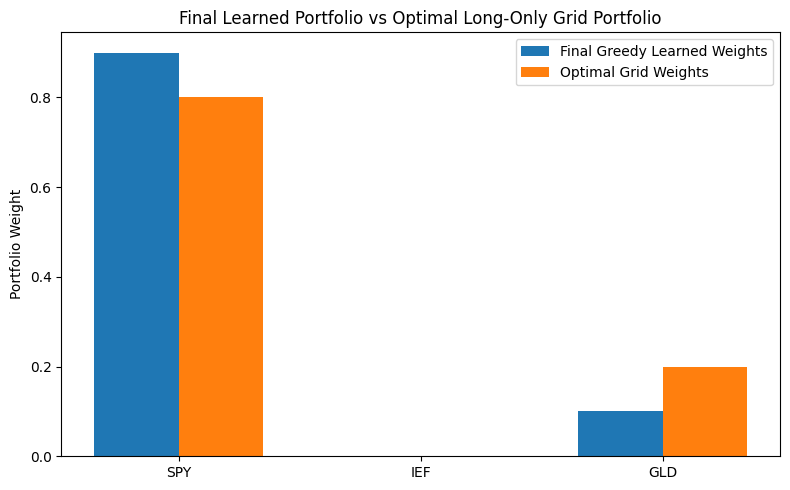

Best hyperparameters:
alpha        0.05
beta        0.002
discount      0.9
seed          123
Name: 172, dtype: object

Final greedy learned weights: [0.9 0.  0.1]
Optimal grid weights: [0.8 0.  0.2]


In [42]:
# ---------------------------------------------------------
# PLOT: FINAL GREEDY LEARNED WEIGHTS vs OPTIMAL GRID WEIGHTS
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

best_row = results_df.sort_values(
    by=["utility_gap_to_grid", "distance_to_grid_benchmark"],
    ascending=[True, True]
).iloc[0]
print("Convergence iteration:", best_row["convergence_iter"])
learned_weights = np.array([
    best_row["w1"],
    best_row["w2"],
    best_row["w3"]
], dtype=float)

optimal_weights = np.array(benchmarks["grid_weights"], dtype=float)

labels = asset_names if "asset_names" in globals() else ["SPY", "IEF", "GLD"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, learned_weights, width, label="Final Greedy Learned Weights")
ax.bar(x + width/2, optimal_weights, width, label="Optimal Grid Weights")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Portfolio Weight")
ax.set_title("Final Learned Portfolio vs Optimal Long-Only Grid Portfolio")
ax.legend()

plt.tight_layout()
plt.show()

print("Best hyperparameters:")
print(best_row[["alpha", "beta", "discount", "seed"]])

print("\nFinal greedy learned weights:", learned_weights)
print("Optimal grid weights:", optimal_weights)